# Entrenaiento de Deep Q-Learning en Flappy Bird

Este notebook contiene el proceso de experimentación y entrenamiento de un agente DQN para resolver el entorno FlappyBird-v0. Implementamos *experience replay* y una red objetivo para estabilizar la aproximación de la función de valor. 

## 1. Preparación del entorno. 

En esta sección configuramos el entorno de ejecución, instalamos las dependencias necesarias y aseguramos la reproducibilidad de los experimentos.

In [1]:
#!git clone https://github.com/rafelsalgueiro/GallegoSalgueiroVera.git

In [2]:
!pip install -q gymnasium flappy-bird-gymnasium torch numpy matplotlib seaborn pygame tqdm

Después de la instalación, realizamos la importación de liberías y configuración.

In [3]:
import os
import pickle
import sys
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm

import gymnasium

project_root = os.path.abspath('.')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.envs.flappy_bird import make_flappy_bird_env
from src.agents.td_agents_dqn import DQNAgent, DQNReplayBuffer
from src.plotting.plotting import (
    plot_rewards, plot_robust_learning_curves, 
    plot_dqn_loss, plot_average_q_values, evaluate_flappy_bird_agent
)

print("Módulos importados con éxito.")

Módulos importados con éxito.


Continuamos con la creación de directorios para almacenar los modelos y resultados y la configuración del dispositivo.

In [4]:
MODELS_DIR = os.path.join(project_root, "models")
RESULTS_DIR = os.path.join(project_root, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuración del dispositivo (GPU si está disponible, sino CPU)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo configurado para entrenamiento: {DEVICE.upper()}")

Dispositivo configurado para entrenamiento: CUDA


Finalmente, aseguramos la reproducibilidad de los experimentos.

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Semilla global fijada en: {seed}")

# Fijamos la semilla inicial
GLOBAL_SEED = 314159
set_seed(GLOBAL_SEED)

Semilla global fijada en: 314159


## 2. Diseño experimental y bucle de entrenamiento

Para evaluar el rendimiento de nuestro agente no nos limitaremos a una sola ejecución, sino que probaremos 3 estrategias distintas:
1. **Estrategia A (baseline)**: DQN estándar con *Target Network* y *Reward Shaping* (`alpha=0.5`).
2. **Estrategia B (sin *target_network*)**: evaluaremos el impacto teórico de la inestabilidad descrita cuando la red principal calcula sus propios objetivos de diferencia temporal.
3. **Estrategia C (sin *reward shaping*)**: entorno puro de Flappy Bird (`alpha=0.0`). Evaluamos si la recompensa dispersa original es suficiente para converger en el mismo tiempo.


In [6]:
# Parámetros globales para el entrenamiento
NUM_EPISODES = 1500     # Episodios por semilla
NUM_SEEDS = 5           # Número de ejecuciones independientes para medir varianza
BATCH_SIZE = 64         # Tamaño del batch para el entrenamiento del DQN
BUFFER_CAPACITY = 10000 # Capacidad del replay buffer
MIN_MEMORY_BEFORE_TRAINING = 1000 # Transiciones mínimas antes de empezar a entrenar

# Hiperparámetros de la red
LR = 1e-3              # Tasa de aprendizaje
GAMMA = 0.99           # Factor de decay de la recompensa
HIDDEN_DIM = 128       # Dimensión de las capas ocultas de la red
TARGET_UPDATE_FREQ = 500 # Frecuencia de actualización de la red objetivo
EPS_START = 1.0        # Valor inicial de epsilon para la política epsilon-greedy
EPS_END = 0.01         # Valor final de epsilon
EPS_DECAY = 0.995      # Factor de decaimiento de epsilon por episodio


En la celda inferior definimos la función genérica para el entrenamiento.

In [7]:
def train_dqn(env, agent, buffer, num_episodes, batch_size, min_memory, max_steps):
    """
    Ejecuta el bucle de entrenamiento estándar de DQN.
    Retorna historiales de recompensas, longitudes, pérdidas y Valores Q máximos.
    """
    history = {
        'rewards': [],
        'lengths': [],
        'losses': [],
        'max_q_values': []
    }
    
    for ep in tqdm(range(num_episodes), desc="Training steps", leave=False):
        state, _ = env.reset()
        done = False
        ep_reward = 0
        ep_length = 0
        ep_losses = []
        ep_max_qs = []
        
        while not done:
            action = agent.get_action(state)
            
            ep_max_qs.append(np.max(agent.get_q_value(state)))
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            buffer.add(state, action, reward, next_state, done)

            if len(buffer) >= min_memory:
                states_b, actions_b, rewards_b, next_states_b, dones_b = buffer.sample(batch_size)
                loss = agent.update_batch(states_b, actions_b, rewards_b, next_states_b, dones_b)
                ep_losses.append(loss)
                
            state = next_state
            ep_reward += reward
            ep_length += 1

            # Delimitamos la longitud máxima del episodio para evitar episodios extremadamente largos
            if ep_length >= max_steps:
                done = True
            
        agent.decay_epsilon()
        
        # Guardar métricas del episodio
        history['rewards'].append(ep_reward)
        history['lengths'].append(ep_length)
        history['losses'].append(np.mean(ep_losses) if ep_losses else 0.0)
        history['max_q_values'].append(np.mean(ep_max_qs) if ep_max_qs else 0.0)
        
    return history

Previamente al entrenamiento, definimos diccionarios para almacenar los resultados y definir las estrategias.

In [8]:
experiment_results = {
    "Baseline (Completo)": [],
    "Sin Target Network": [],
    "Sin Reward Shaping": []
}

# Definición de las estrategias (nombre: kwargs para entorno y agente)
strategies = {
    "A - Baseline (Completo)": {"alpha_env": 0.5, "use_target": True},
    "B - Sin Target Network":  {"alpha_env": 0.5, "use_target": False},
    "C - Sin Reward Shaping":  {"alpha_env": 0.0, "use_target": True}
}

Sin nada más que añadir, realizamos los entrenamientos.

In [ ]:
for strategy_name, config in strategies.items():
    print(f"Iniciando entrenamiento de la estrategia: {strategy_name}")
    
    # Matriz para almacenar las recompensas de todas las semillas (para plot_robust_learning_curves)
    seed_rewards = np.zeros((NUM_SEEDS, NUM_EPISODES))
    
    for seed_idx in range(NUM_SEEDS):
        current_seed = GLOBAL_SEED + seed_idx
        set_seed(current_seed) # Reiniciamos la semilla
        print(f"  -> Ejecutando Semilla {seed_idx + 1}/{NUM_SEEDS} (Seed: {current_seed})")
        
        # Entorno
        env = make_flappy_bird_env(alpha=config["alpha_env"], count_negative_rewards=False)
        env.action_space.seed(current_seed)
        
        # Agente y Buffer
        agent = DQNAgent(
            env=env, alpha=LR, gamma=GAMMA, epsilon_start=EPS_START, 
            epsilon_min=EPS_END, epsilon_decay=EPS_DECAY, hidden_dim=HIDDEN_DIM, 
            use_target_network=config["use_target"], target_update_freq=TARGET_UPDATE_FREQ,
            device=DEVICE
        )
        buffer = DQNReplayBuffer(capacity=BUFFER_CAPACITY, state_dim=env.observation_space.shape[0])
        
        # Entrenar
        history = train_dqn(env, agent, buffer, NUM_EPISODES, BATCH_SIZE, MIN_MEMORY_BEFORE_TRAINING, max_steps=10000)
        
        # Guardar resultados
        seed_rewards[seed_idx, :] = history['rewards']
        
        # Guardar el modelo de la última semilla de cada estrategia
        if seed_idx == NUM_SEEDS - 1:
            model_path = os.path.join(MODELS_DIR, f"dqn_{strategy_name.replace(' ', '_')}.pth")
            agent.save_weights(model_path)
            # Guardamos el historial de la última semilla para las gráficas de loss y Q-values
            experiment_results[f"{strategy_name}_last_history"] = history
            
        env.close()
        
    # Guardamos la matriz de recompensas robustas
    experiment_results[strategy_name] = seed_rewards

results_path = os.path.join(RESULTS_DIR, "experiment_results_dqn.pkl")
with open(results_path, "wb") as f:
    torch.save(experiment_results, f)

print("\n¡Experimento finalizado con éxito!")

Iniciando entrenamiento de la estrategia: A - Baseline (Completo)
Semilla global fijada en: 314159
  -> Ejecutando Semilla 1/5 (Seed: 314159)


Semilla global fijada en: 314160
  -> Ejecutando Semilla 2/5 (Seed: 314160)


Semilla global fijada en: 314161
  -> Ejecutando Semilla 3/5 (Seed: 314161)


Semilla global fijada en: 314162
  -> Ejecutando Semilla 4/5 (Seed: 314162)


Semilla global fijada en: 314163
  -> Ejecutando Semilla 5/5 (Seed: 314163)


...

Semilla global fijada en: 314160
  -> Ejecutando Semilla 2/5 (Seed: 314160)


Semilla global fijada en: 314161
  -> Ejecutando Semilla 3/5 (Seed: 314161)


Semilla global fijada en: 314162
  -> Ejecutando Semilla 4/5 (Seed: 314162)


Semilla global fijada en: 314163
  -> Ejecutando Semilla 5/5 (Seed: 314163)


Pesos guardados en /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_C_-_Sin_Reward_Shaping.pth

¡Experimento finalizado con éxito!


## 3. Análisis de resultados

Finalizado el entrenamiento, procedemos a analizar empíricamente su rendimiento. 

### 3.1. Curvas de aprendizaje

En primer lugar, visualizaremos las currvas de aprendizaje que muestran la recompensa media acumulada y su varianza calculada sobre las diferentes semillas.

Resultados cargados desde disco exitosamente.
Generando Gráfica de Rendimiento Comparativo...


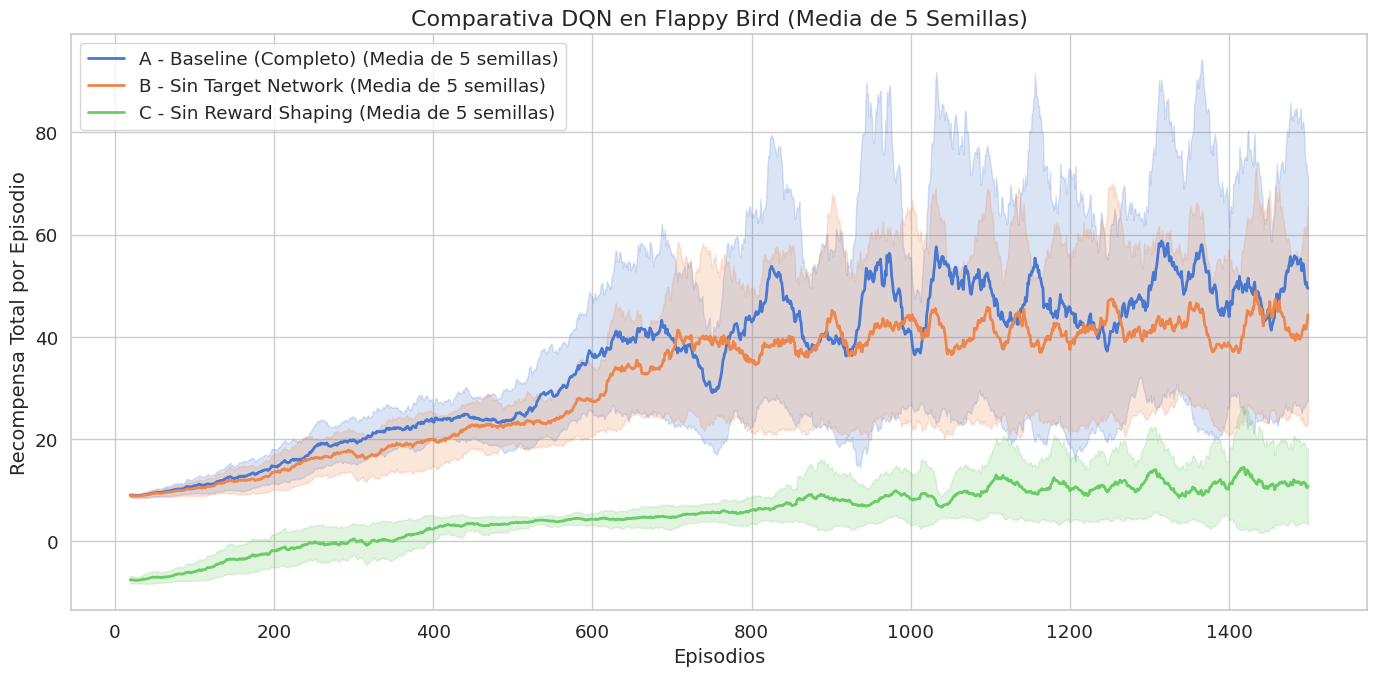

In [8]:
# Extraemos los resultads de fichero para evitar tener que ejecutar el entrenamiento cada vez que queramos graficar
results_path = os.path.join(RESULTS_DIR, "experiment_results_dqn.pkl")

if os.path.exists(results_path):
    with open(results_path, 'rb') as f:
        experiment_results = pickle.load(f)
    print("Resultados cargados desde disco exitosamente.")
else:
    print("No se encontró el archivo de resultados. Ejecuta la celda de entrenamiento primero.")

rewards_data = {
    k: v for k, v in experiment_results.items() 
    if not k.endswith("_last_history") and len(v) > 0
}

print("Generando Gráfica de Rendimiento Comparativo...")
plot_robust_learning_curves(
    data_dict=rewards_data,
    window_size=20, # Suavizado medio
    title=f"Comparativa DQN en Flappy Bird (Media de {NUM_SEEDS} Semillas)",
    ylabel="Recompensa Total por Episodio"
)

Podemos comenzar con la gráfica de la evolución media de la recompensa total por episodio a lo largo de 1500 iteraciones promediada por las 5 semillas. De esta visión podemos extraer las siguientes observaciones:
1. Necesidad de *reward shaping*: la **estrategia C** (verde) comienza con puntuaciones negativas y apenas logra superar la recompensa de 10. Esto se debe, en parte, a que esta metodología recibe una fuente menos de recompensas, por lo que este fenómeno no es suficiente para extraer un veredicto.
2. Inestabilidad por ausencia de red objetio: la teoría del control off-policy con aproximaciones advierte que actualizar una red neuronal utilizando estimaciones calculadas por ella misma en el mismo instante de tiempo genera el problema del "objetivo móvil". Nuestra gráfica lo confirma empíricamente: casi en todo momento la **estrategia B** (naranja) se encuentra por debejo de la **estrategia A** azul, en cuanto a recompensa media y máxima.
3. Varianza: observamos que la **estrategia A** presenta una línea sombreada muy amplia, indicando una alta varianza entre semillas. Esto ilustra una sensibilidad en la inicialización de los pesos y a las primeras muestras aleatorias del *buffer* de repetición. Mostrar esta varianza justifica nuestra decisión de evaluar sobre 5 ejecuciones independientes.

Antes de extraer conclusiones, analicemos las redes obtenidas.

### 3.2. Análisis interno de la estrategia A

Tras confirmar empíricamente una superioridad de la estrategia A sobre la B, procedemos con un análisis más profundo la red obtenida en una de las ejecuciones. Más allá de la recompensa externa obtenida en el entorno, queremos entetnder el comportamiento interno de la red neuronal a lo largo del proceso de entrenamiento. Para ello, aislamos el historial de la última semilla de la misma y analizamos dos métricas registradas durante su entrenamiento.

Generando Gráfica de Pérdida (Loss)...


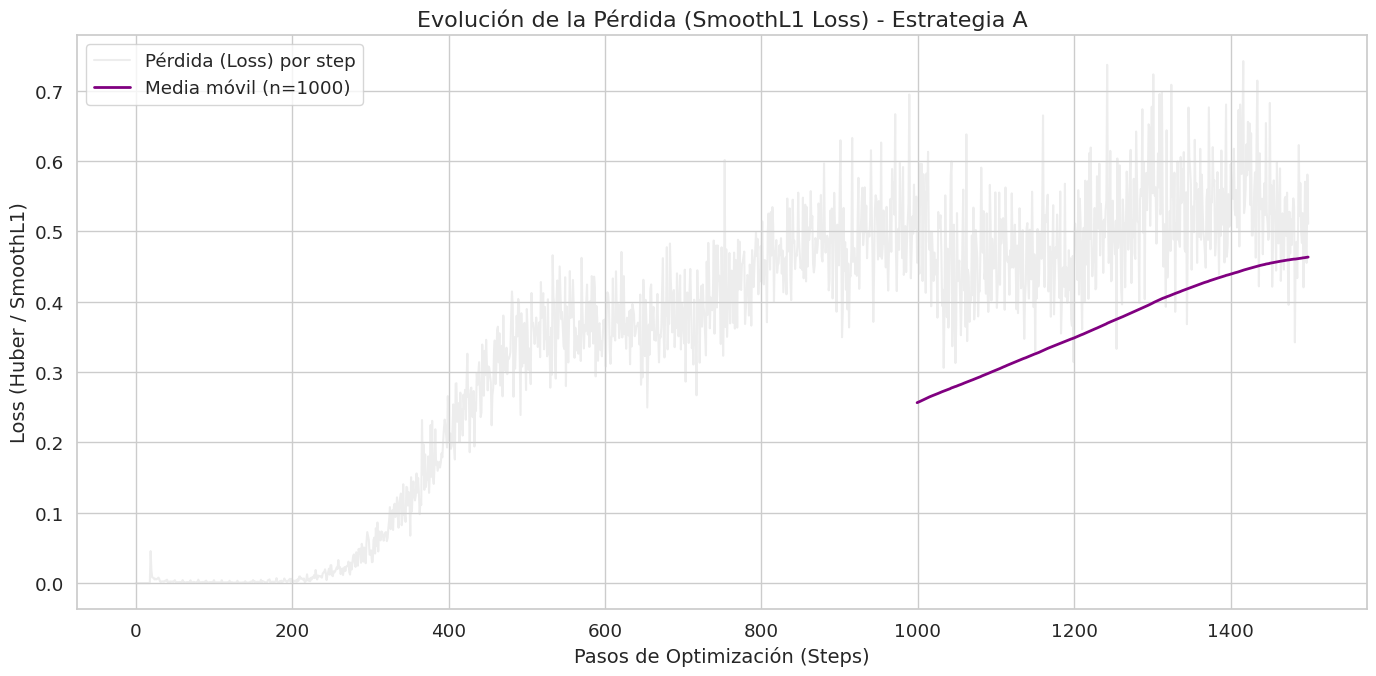

Generando Gráfica de Estimación de Valores Q...


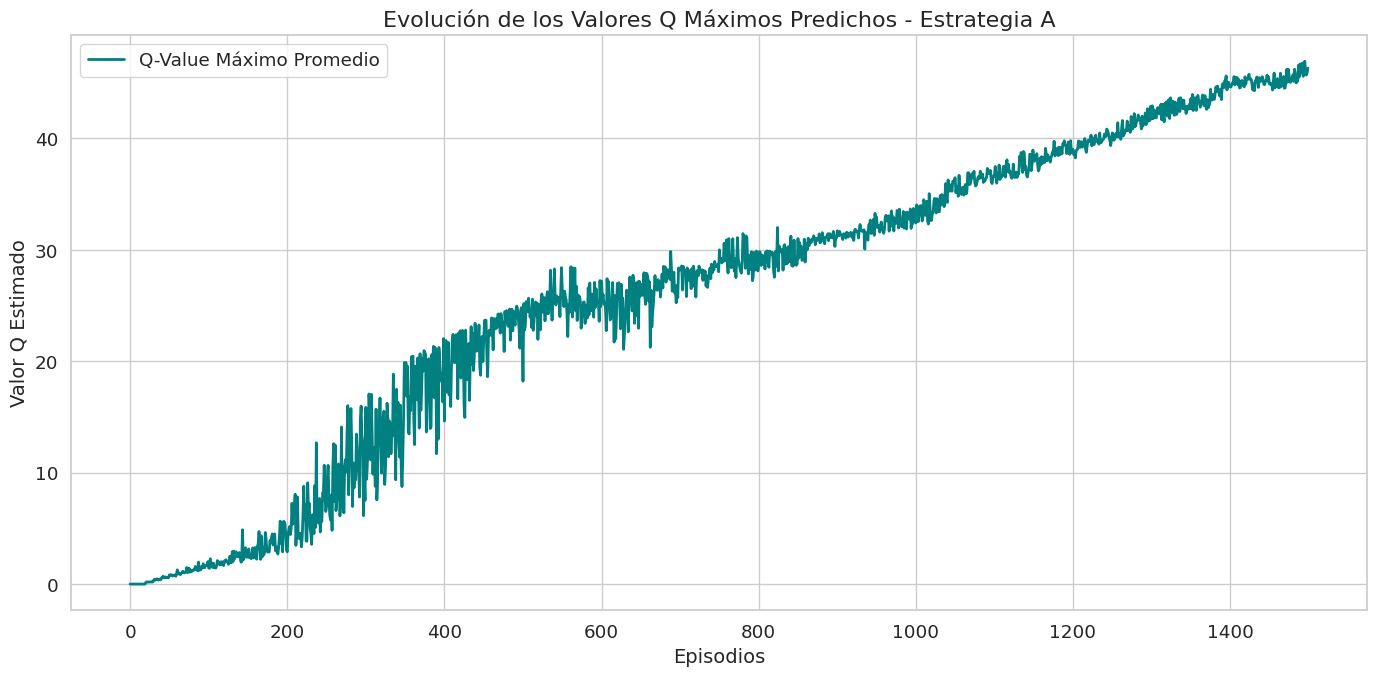

In [9]:
baseline_history = experiment_results.get("A - Baseline (Completo)_last_history")

if baseline_history:
    print("Generando Gráfica de Pérdida (Loss)...")
    plot_dqn_loss(
        losses=baseline_history['losses'], 
        window_size=1000, # Usamos un suavizado grande porque el loss por step (batch) fluctúa muchísimo
        title="Evolución de la Pérdida (SmoothL1 Loss) - Estrategia A"
    )
    
    print("Generando Gráfica de Estimación de Valores Q...")
    plot_average_q_values(
        avg_q_values=baseline_history['max_q_values'],
        title="Evolución de los Valores Q Máximos Predichos - Estrategia A"
    )
else:
    print("Error: No se encontró el historial detallado del Baseline en el diccionario.")

La gráfica de pérdida muestra el error entre las predicciones de la red principal y los *targets* calculados.
- Fase inicial (0-200 pasos): observamos una pérdida muy cercana a cero. Esto se debe a que el *replay buffer* se está llenando y la red esta prediciendo valores casi nulos porque sus pesos iniciales son pequeños.
- Fase de descubrimiento (200-800 pasos): se produce un salto brusco en la pérdida. Esto coincide con el momento en que el agente cominza a vivir un poco más y recibe recompensas positivas más altas atravesando tubos.
- Fase de estabilización: (800- pasos): a pesar de la alta varianza en el muestreo, la tendencia de la pérdida no es un crecimiento descontrolado, sino que se mantiene de forma positiva pero acotada a medida que el horizonte temporal del supervivencia (y por tanto la recompensa esperada) se amplía.

Por otro lado, la estimación de valores Q predichos confirma una tendencia creciente y correlacionada con el aumento de la supervivencia del agente. Gracias al uso de una *target network* independiente, observamos que el crecimiento de los valores Q reduce su varianza a partir de los 800 episodios.

### 3.3. Análisis interno de la estrategia C

Como comentábamos en el apartado 3.1., la estrategia C utiliza un método distinto de evaluación que hace injusta la comparación con el resto de estrategias. Así pues, dediquémosle el mismo análisis que a la estrategia A para extraer alguna conclusión.

Generando Gráfica de Pérdida (Loss) para Estrategia C...


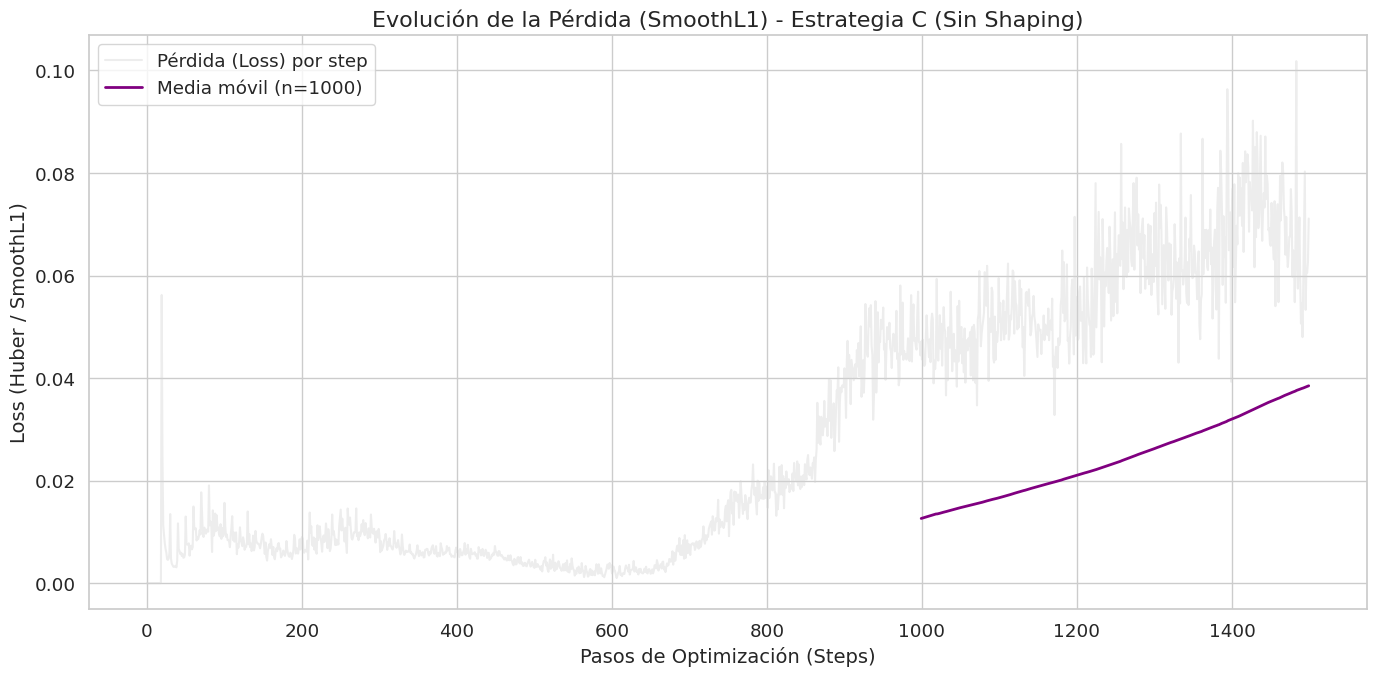

Generando Gráfica de Estimación de Valores Q para Estrategia C...


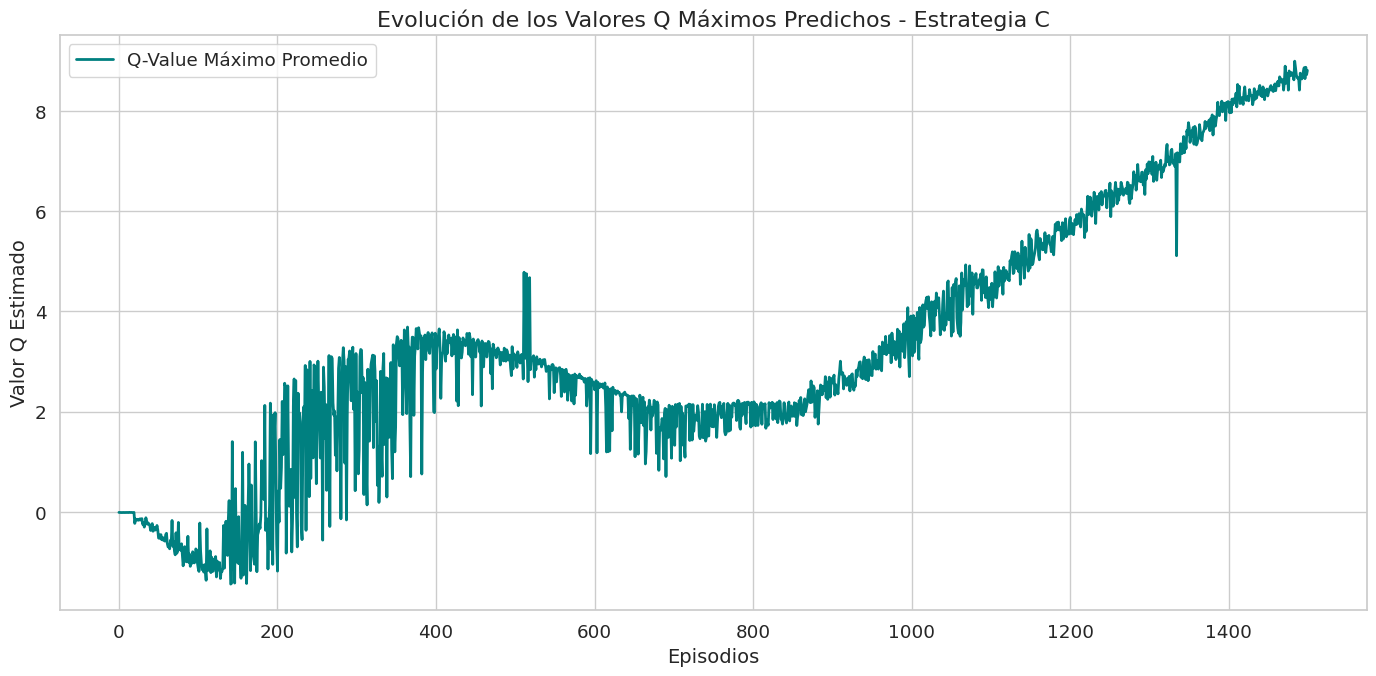

In [12]:
strategy_c_history = experiment_results.get("C - Sin Reward Shaping_last_history")

if strategy_c_history:
    print("Generando Gráfica de Pérdida (Loss) para Estrategia C...")
    plot_dqn_loss(
        losses=strategy_c_history['losses'], 
        window_size=1000, 
        title="Evolución de la Pérdida (SmoothL1) - Estrategia C (Sin Shaping)"
    )
    
    print("Generando Gráfica de Estimación de Valores Q para Estrategia C...")
    plot_average_q_values(
        avg_q_values=strategy_c_history['max_q_values'],
        title="Evolución de los Valores Q Máximos Predichos - Estrategia C"
    )
else:
    print("Error: No se encontró el historial detallado de la Estrategia C.")

Al analizar la dinámica interna de la **estrategia C** observamos diferencias notables con la **estrategia A**.

Esta vez comenzamos analizando la gráfica de los valores Q. El agente comienza prediciendo valores negativos debido a que el pájaro se estrella en los 10 primeros frames del juego (-1.0 de recompensa por estrellarse y +0.1 por sobrevivir). Después de esto, se mantiene con predicciones positivas pero muy bajas, pues la red aprende que cualquier estado conduce irremediablemente a un castigo. No esta hasta pasada la mitad del entrenaiento que el agente logra encadenar suficientes pasos a través de tubos para que el retorno acumulado esperado supere el castigo de colisión final. Asimismo, tal y como anticipábamos, la magnitud final a la que convergen los valores Q es significativamente menor (rondando un valor de 8-9, frente a los 45 de la estrategia A. Esto confirma que las redes están aproximando funciones de valor matemáticamente diferentes).

La gráfica de pérdida es igualmente reveladora si prestamos atención a su escala y tendencia:
- Baja magnitud en estapas iniciales: durante la primera mitad del entrenamiento, el error se mantiene bajo (por debajo de 0.02) y plano. Esto ocurre porque la red predice de forma sencilla su fracaso.
- Cambio de tendencia a partir de la etapa 800: justo cuando los valores Q empiezan a remontar se produce una explosión de la pérdida. Esto se debe presumiblemente a que el agente empieza a encontrarse con tubos al azar y la red recibe objetivos TD positivos inesperados que rompen sus predicciones psimistas. Este pico de error es indicativo de que la red por fin se está reajustando hacia una política exitosa.


### 4. Comparativa de rendimiento real

Dado que la **estrategia A** y la **Estrategia C** fueron entrenadas en espacios de recompensa diferentes, la comparación directa de sus curvas de entrenamiento presenta sesgos. Para determinar de forma justa cuál de los dos agentes ha desarrollado una política más competente para jugar a Flappy Bird, realizamos una evaluación final por torneo. En esta fase:
1. Instanciamos un entorno puro (`alpha=0.0`), donde la única forma de ganar puntos es pasando tuberías.
2. Desactivamos por completo la exploración del agente ($\epsilon=0.0$), forzándolo a actuar siempre en base a su política.
3. Evaluamos cada modelo en episodios independientes y comparamos la puntuación real media obtenida.

In [12]:
def evaluate_true_score(model_path, env, num_episodes=20):
    """Evalúa un agente cargando sus pesos y midiendo la puntuación real del juego."""
    # Instanciamos un agente genérico sin exploración
    eval_agent = DQNAgent(
        env=env, alpha=LR, gamma=GAMMA, epsilon_start=0.0, 
        hidden_dim=HIDDEN_DIM, device=DEVICE
    )
    
    # Cargamos los pesos entrenados
    if not eval_agent.load_weights(model_path):
        return 0.0
        
    scores = []
    
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        score = 0
        
        while not done:
            action = eval_agent.get_action(state)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            if done:
                score = info.get('score', 0)
                scores.append(score)
                
    return np.mean(scores), np.std(scores), scores

print("Iniciando evaluación final de estrategias.")

# Entorno puramente original (sin shaping)
env_eval = make_flappy_bird_env(alpha=0.0, count_negative_rewards=False)
NUM_EPISODES_FINAL = 1000

# Rutas a los modelos (Asegúrate de que los nombres coinciden con los guardados en la carpeta models)
path_model_A = os.path.join(MODELS_DIR, "dqn_A_-_Baseline_(Completo).pth")
path_model_C = os.path.join(MODELS_DIR, "dqn_C_-_Sin_Reward_Shaping.pth")

# Evaluación Estrategia A
print("\nEvaluando Estrategia A (Baseline)...")
mean_A, std_A, scores_A = evaluate_true_score(path_model_A, env_eval, num_episodes=NUM_EPISODES_FINAL)

# Evaluación Estrategia C
print("\nEvaluando Estrategia C (Sin Shaping)...")
mean_C, std_C, scores_C = evaluate_true_score(path_model_C, env_eval, num_episodes=NUM_EPISODES_FINAL)

env_eval.close()

print("\n" + "="*40)
print(f"Resultado del torneo de evaluación final ({NUM_EPISODES_FINAL} episodios por estrategia)")
print("="*40)
print(f"Estrategia A (Con Shaping): Media = {mean_A:.2f} tubos | Desv = {std_A:.2f}")
print(f"Estrategia C (Sin Shaping): Media = {mean_C:.2f} tubos | Desv = {std_C:.2f}")
print("="*40)

plt.figure(figsize=(8, 5))
sns.boxplot(data=[scores_A, scores_C], palette=["#4c72b0", "#55a868"])
plt.xticks([0, 1], ["Estrategia A\n(Entrenada con Shaping)", "Estrategia C\n(Entrenada sin Shaping)"])
plt.ylabel("Tubos superados (Puntuación Real)", fontsize=12)
plt.title("Rendimiento Real en el Entorno Puro ($\epsilon=0$)", fontsize=14)
plt.tight_layout()
plt.show()

<>:62: SyntaxWarning: invalid escape sequence '\e'
<>:62: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_135229/3825532495.py:62: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Rendimiento Real en el Entorno Puro ($\epsilon=0$)", fontsize=14)


Iniciando evaluación final de estrategias.

Evaluando Estrategia A (Baseline)...
Pesos cargados desde /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_A_-_Baseline_(Completo).pth


/tmp/ipykernel_135229/3825532495.py:62: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Rendimiento Real en el Entorno Puro ($\epsilon=0$)", fontsize=14)


KeyboardInterrupt: 

Los resultados revelan una paridad casi absoluta entre ambas estrategias (media de 3.69 frente a 3.80, con desviaciones típicas similares). De este empate podemos estraer las siguientes conclusiones:
- Dado que la **estrategia C** logra jugar igual de bien que la **estrategia A** al finalizar los 1500 episodios de entrenamiento, pudiera parecer que el *reward shaping* es innecesario. No obstante, si cruzamos este dato con nuestras gráficas de entrenamiento la realidad es muy distinta. La **estrategia C** pasó la mitad del proceso de entrenamiento dependiendo de la suerte para encontrar los primeros tubos. Por su parte, la **estrategia A**, gracias a la recompensa por mantenerse en el centro, presentó una convergencia estable y rápida desde los instantes iniciales. Modificar la función de recompensa en etapas iniciales puede, pues, actuar como catalizador.
- La función de penalización basada en la heurística de buscar el centro de los tubos está justificada. El modelo final es capaz de jugar igual de bien que el que utiliza la recompensa base.

## 5. Aprendizaje mixto

Visto los resultados obtenidos hasta ahora nos aparece la curiosidad de comprobar si nos es posible crear en un tiempo corto un "jugador perfecto". Así pues, en base a los resultados obtenidos decidimos combinar la rapidez de convergenicia de la **estrategia A** con la sencillez y robustez de la **estrategia C**. Para ello, no podemos tomar un episodio fijo y retirar la recompensa controlada por `alpha`. Así pues, nuestra estrategia mixta consiste en:
1. Mantener la **estrategia A** los primeros 600 episodios.
2. Decaer `alpha` de forma lineal hasta llegar a 0 tras 1000 episodios: 
$$\alpha_t = \frac{800-0.5t}{1000},\,600\leq t \leq 1600$$
3. Dejar `alpha=0.0` de este punto en adelante.

In [8]:
print("Iniciando Entrenamiento del agente final (Curriculum + Reseteos + Checkpointing)")

NUM_EPISODES_PERFECT = 20000
BUFFER_CAPACITY = 50000
INITIAL_ALPHA = 0.5

set_seed(9999)

env_perfect = make_flappy_bird_env(alpha=INITIAL_ALPHA, count_negative_rewards=False)

agent_perfect = DQNAgent(
    env=env_perfect, alpha=LR, gamma=GAMMA, epsilon_start=EPS_START, 
    epsilon_min=EPS_END, epsilon_decay=0.995, hidden_dim=HIDDEN_DIM, 
    use_target_network=True, target_update_freq=TARGET_UPDATE_FREQ, device=DEVICE
)
buffer_perfect = DQNReplayBuffer(capacity=BUFFER_CAPACITY, state_dim=env_perfect.observation_space.shape[0])

history_perfect = {
    'rewards': [], 'true_scores': [], 'lengths': [], 'alphas': [],
    'losses': [], 'max_q_values': []
}

best_mean_score = -float('inf')
recent_scores_window = []

for ep in tqdm(range(NUM_EPISODES_PERFECT), desc="Entrenando Agente Definitivo"):
    
    state, _ = env_perfect.reset()
    done = False
    ep_reward = 0
    ep_length = 0
    true_score = 0
    ep_losses = []
    ep_max_qs = []

    # 1. CURRICULUM LEARNING
    # Decay alpha over 5000 episodes instead of 1000
    if ep < 600:
        current_alpha = 0.5
    elif 600 <= ep <= 5600:
        current_alpha = 0.5 * (1 - (ep - 600) / 5000.0)
    else:
        current_alpha = 0.0

    env_perfect.set_alpha(current_alpha)
    history_perfect['alphas'].append(current_alpha)

    # 2. RESETEO DE EPSILON
    if ep == 1600:
            print(f"\nReseteando el epsilon en el episodio {ep} para evitar estancamiento.")
            agent_perfect.epsilon = 0.3
            for param_group in agent_perfect.optimizer.param_groups:
                param_group['lr'] = LR 
    
    while not done:
        action = agent_perfect.get_action(state)
        ep_max_qs.append(np.max(agent_perfect.get_q_value(state)))
        
        next_state, reward, terminated, truncated, info = env_perfect.step(action)
        done = terminated or truncated
        
        buffer_perfect.add(state, action, reward, next_state, done)
        
        if len(buffer_perfect) >= MIN_MEMORY_BEFORE_TRAINING:
            states_b, actions_b, rewards_b, next_states_b, dones_b = buffer_perfect.sample(BATCH_SIZE)
            loss = agent_perfect.update_batch(states_b, actions_b, rewards_b, next_states_b, dones_b)
            ep_losses.append(loss)
            
        state = next_state
        ep_reward += reward
        ep_length += 1
        
        if done:
            true_score = info.get('score', 0)
            
        if ep_length >= 10000:
            done = True
            
    agent_perfect.decay_epsilon()
    
    history_perfect['rewards'].append(ep_reward)
    history_perfect['true_scores'].append(true_score)
    history_perfect['lengths'].append(ep_length)
    history_perfect['losses'].append(np.mean(ep_losses) if ep_losses else 0.0)
    history_perfect['max_q_values'].append(np.mean(ep_max_qs) if ep_max_qs else 0.0)

    # 3. CHECKPOINTING (Guardado del mejor modelo)
    recent_scores_window.append(true_score)
    if len(recent_scores_window) > 100:
        recent_scores_window.pop(0) 
    
    if ep > 1600 and len(recent_scores_window) == 100:
        current_mean = np.mean(recent_scores_window)
        if current_mean > best_mean_score:
            best_mean_score = current_mean
            path_perfect_model = os.path.join(MODELS_DIR, "dqn_Agente_Definitivo.pth")
            agent_perfect.save_weights(path_perfect_model)

env_perfect.close()

# SOLO GUARDAMOS EL HISTORIAL AL FINAL
results_path_perfect = os.path.join(RESULTS_DIR, "experiment_results_perfect.pkl")
with open(results_path_perfect, 'wb') as f:
    pickle.dump(history_perfect, f)

print(f"\nFinalización del entrenamiento. El MEJOR modelo alcanzó una media de {best_mean_score:.2f} y ha sido protegido en: {path_perfect_model}")

Iniciando Entrenamiento del agente final (Curriculum + Reseteos + Checkpointing)
Semilla global fijada en: 9999


Entrenando Agente Definitivo:   8%|▊         | 1602/20000 [02:25<31:25,  9.76it/s]  


Reseteando el epsilon en el episodio 1600 para evitar estancamiento.
Pesos guardados en /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_Agente_Definitivo.pth


Entrenando Agente Definitivo:  10%|█         | 2038/20000 [03:07<42:50,  6.99it/s]

Pesos guardados en /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_Agente_Definitivo.pth
Pesos guardados en /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_Agente_Definitivo.pth


...

Pesos guardados en /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_Agente_Definitivo.pth


Entrenando Agente Definitivo:  69%|██████▉   | 13836/20000 [32:35<33:03,  3.11it/s]

Pesos guardados en /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_Agente_Definitivo.pth


Entrenando Agente Definitivo: 100%|██████████| 20000/20000 [53:36<00:00,  6.22it/s]  


Finalización del entrenamiento. El MEJOR modelo alcanzó una media de 5.88 y ha sido protegido en: /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_Agente_Definitivo.pth


### 5.1. Gráficas del agente

Generando Gráfica de Pérdida (Loss)...


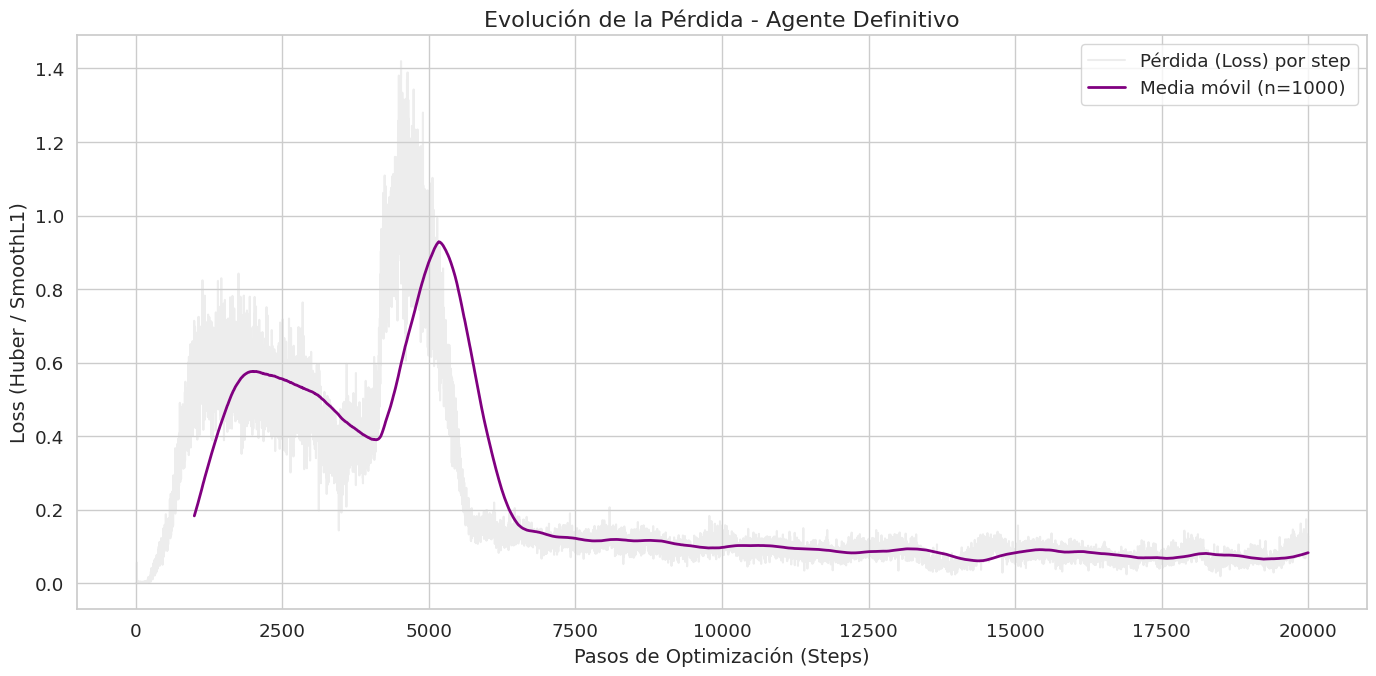

Generando Gráfica de Estimación de Valores Q...


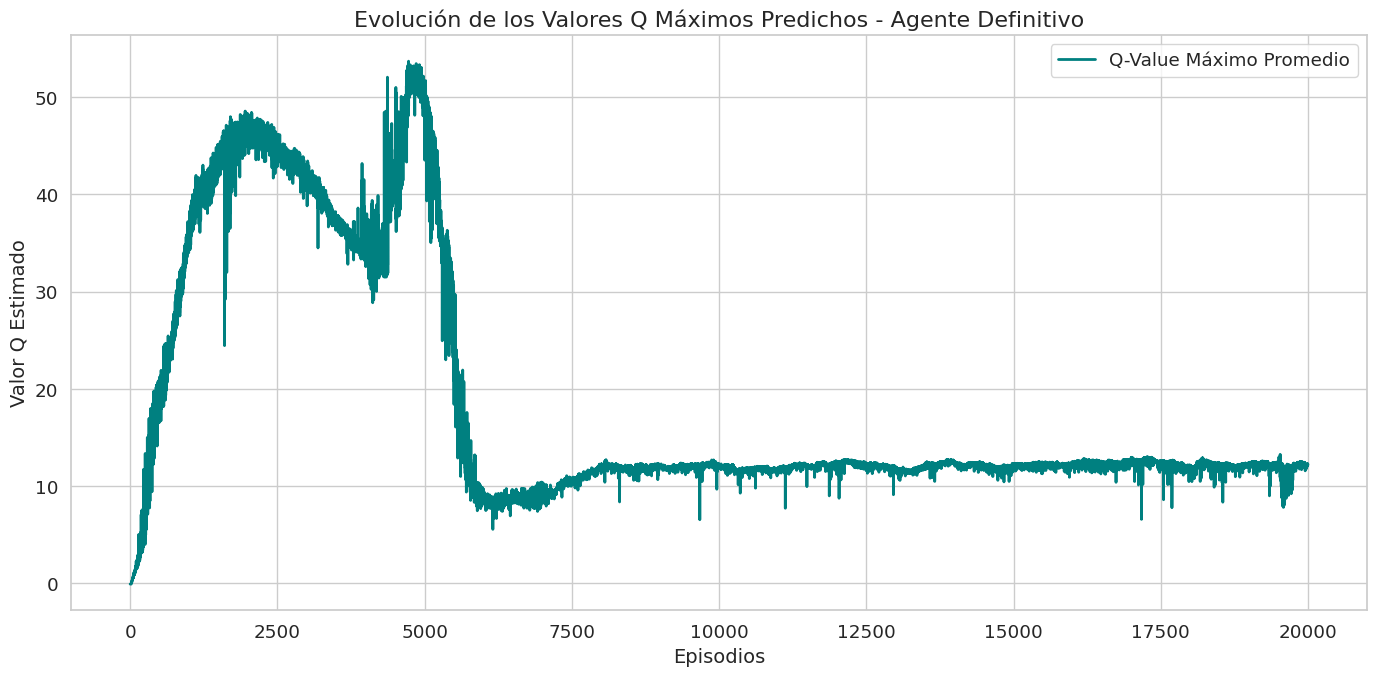

Generando Gráfica de Puntuación Real (Tubos pasados)...


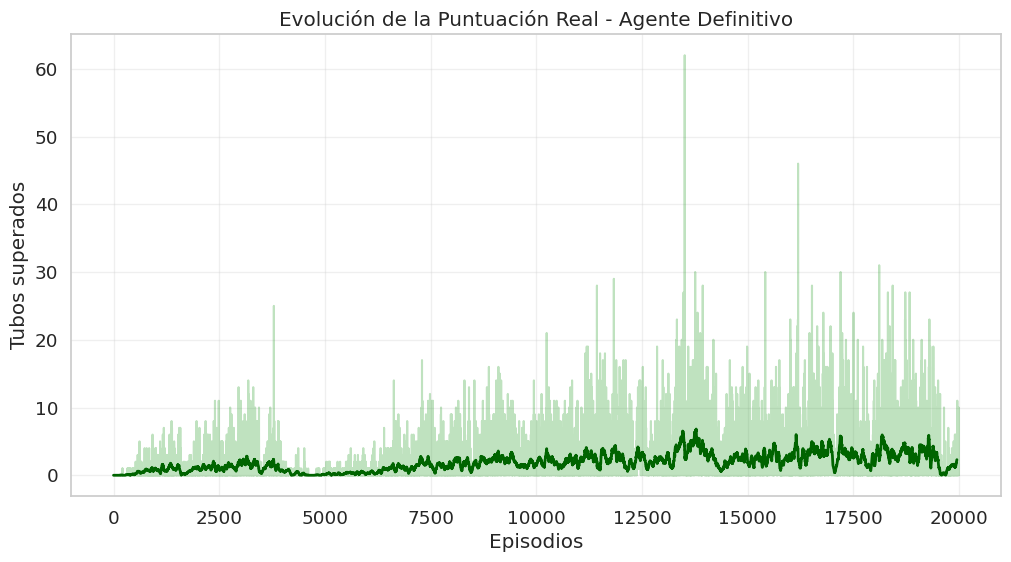

Generando Gráfica de Decaimiento de Alpha...


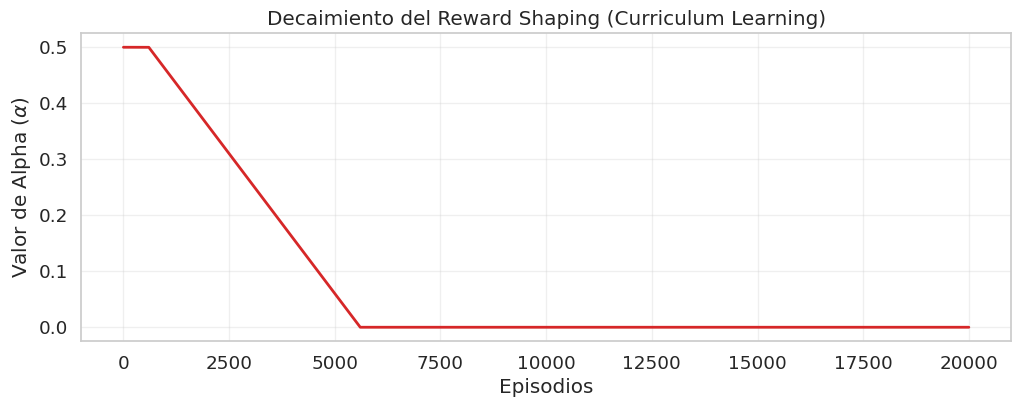

In [9]:
print("Generando Gráfica de Pérdida (Loss)...")
plot_dqn_loss(
    losses=history_perfect['losses'], 
    window_size=1000, 
    title="Evolución de la Pérdida - Agente Definitivo"
)

print("Generando Gráfica de Estimación de Valores Q...")
plot_average_q_values(
    avg_q_values=history_perfect['max_q_values'],
    title="Evolución de los Valores Q Máximos Predichos - Agente Definitivo"
)

print("Generando Gráfica de Puntuación Real (Tubos pasados)...")
plt.figure(figsize=(12, 6))
plt.plot(history_perfect['true_scores'], color='#2ca02c', alpha=0.3)
plt.plot(np.convolve(history_perfect['true_scores'], np.ones(50)/50, mode='valid'), color='#006400', linewidth=2)
plt.title("Evolución de la Puntuación Real - Agente Definitivo")
plt.xlabel("Episodios")
plt.ylabel("Tubos superados")
plt.grid(True, alpha=0.3)
plt.show()

print("Generando Gráfica de Decaimiento de Alpha...")
plt.figure(figsize=(12, 4))
plt.plot(history_perfect['alphas'], color='#d62728', linewidth=2)
plt.title("Decaimiento del Reward Shaping (Curriculum Learning)")
plt.xlabel("Episodios")
plt.ylabel("Valor de Alpha ($\\alpha$)")
plt.grid(True, alpha=0.3)
plt.show()

## 5.2. Comparación con las estrategias puras

Veamos si esta estrategia mixta ha merecido la pena.

<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_135229/2508739670.py:51: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Rendimiento Asintótico en el Entorno Puro ($\epsilon=0$)", fontsize=14, pad=15)


=== INICIANDO GRAN TORNEO DE EVALUACIÓN FINAL ===

[1/3] Evaluando Estrategia A (Shaping Fijo) durante 1000 episodios...
Pesos cargados desde /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_A_-_Baseline_(Completo).pth

[2/3] Evaluando Estrategia C (Sin Shaping) durante 1000 episodios...
Pesos cargados desde /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_C_-_Sin_Reward_Shaping.pth

[3/3] Evaluando Agente Definitivo (Curriculum Learning) durante 1000 episodios...
Pesos cargados desde /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_Agente_Definitivo.pth

🏆 RESULTADOS DEL GRAN TORNEO FINAL (1000 Episodios) 🏆
Estrategia A (Shaping Fijo):      Media = 3.48 | Desv = 4.09
Estrategia C (Sin Shaping):       Media = 3.85 | Desv = 4.75
Agente Definitivo (Curriculum):   Media = 9.81 | Desv = 9.68


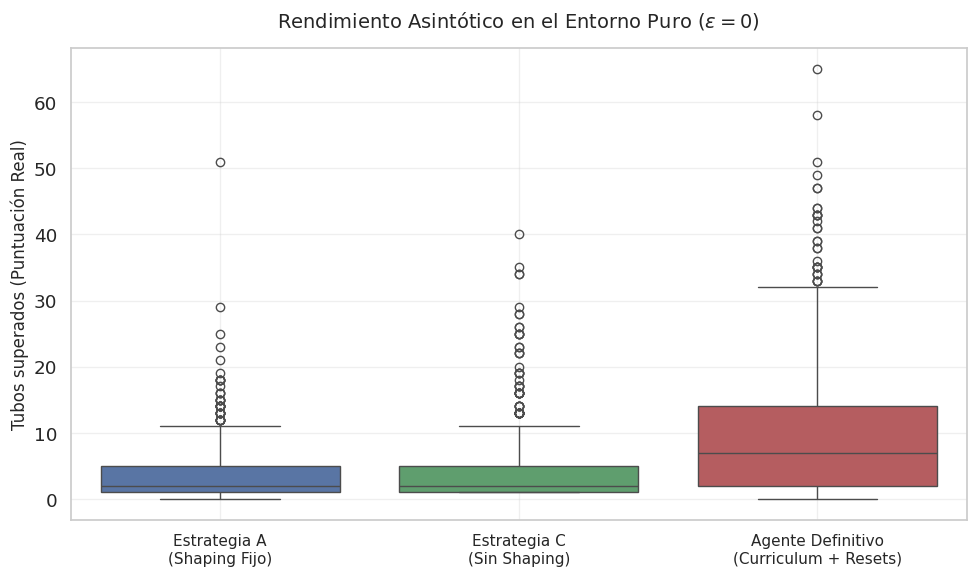

In [13]:

print("=== INICIANDO GRAN TORNEO DE EVALUACIÓN FINAL ===")

# Instanciamos el entorno puro (alpha=0.0) para que la evaluación sea justa
env_eval = make_flappy_bird_env(alpha=0.0, count_negative_rewards=False)

# Rutas a los modelos guardados
path_model_A = os.path.join(MODELS_DIR, "dqn_A_-_Baseline_(Completo).pth")
path_model_C = os.path.join(MODELS_DIR, "dqn_C_-_Sin_Reward_Shaping.pth")
path_model_Perfect = os.path.join(MODELS_DIR, "dqn_Agente_Definitivo.pth")

NUM_EPISODIOS_EVAL = 1000

# Evaluación Estrategia A
print(f"\n[1/3] Evaluando Estrategia A (Shaping Fijo) durante {NUM_EPISODIOS_EVAL} episodios...")
mean_A, std_A, scores_A = evaluate_true_score(path_model_A, env_eval, num_episodes=NUM_EPISODIOS_EVAL)

# Evaluación Estrategia C
print(f"\n[2/3] Evaluando Estrategia C (Sin Shaping) durante {NUM_EPISODIOS_EVAL} episodios...")
mean_C, std_C, scores_C = evaluate_true_score(path_model_C, env_eval, num_episodes=NUM_EPISODIOS_EVAL)

# Evaluación Agente Definitivo
print(f"\n[3/3] Evaluando Agente Definitivo (Curriculum Learning) durante {NUM_EPISODIOS_EVAL} episodios...")
mean_Perfect, std_Perfect, scores_Perfect = evaluate_true_score(path_model_Perfect, env_eval, num_episodes=NUM_EPISODIOS_EVAL)

env_eval.close()

# Imprimir Resultados en Consola
print("\n" + "="*60)
print("🏆 RESULTADOS DEL GRAN TORNEO FINAL (1000 Episodios) 🏆")
print("="*60)
print(f"Estrategia A (Shaping Fijo):      Media = {mean_A:.2f} | Desv = {std_A:.2f}")
print(f"Estrategia C (Sin Shaping):       Media = {mean_C:.2f} | Desv = {std_C:.2f}")
print(f"Agente Definitivo (Curriculum):   Media = {mean_Perfect:.2f} | Desv = {std_Perfect:.2f}")
print("="*60)

# Generar Boxplot Comparativo
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=[scores_A, scores_C, scores_Perfect], 
    palette=["#4c72b0", "#55a868", "#c44e52"]
)
plt.xticks([0, 1, 2], [
    "Estrategia A\n(Shaping Fijo)", 
    "Estrategia C\n(Sin Shaping)", 
    "Agente Definitivo\n(Curriculum + Resets)"
], fontsize=11)
plt.ylabel("Tubos superados (Puntuación Real)", fontsize=12)
plt.title("Rendimiento Asintótico en el Entorno Puro ($\epsilon=0$)", fontsize=14, pad=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Visualización

In [35]:
# Elegir el modelo
import time
import gymnasium


model_filename = "dqn_A_-_Baseline_(Completo).pth" 

model_path = os.path.join(MODELS_DIR, model_filename)

try:
    env_render = make_flappy_bird_env(alpha=0.0, count_negative_rewards=False, render_mode="human")
except TypeError:
    env_render = gymnasium.make("FlappyBird-v0", render_mode="human")

# Instanciar el agente (forzamos epsilon a 0.0 para que sea 100% greedy)
agent_render = DQNAgent(
    env=env_render, alpha=LR, gamma=GAMMA, epsilon_start=0.0, 
    epsilon_min=0.0, epsilon_decay=1.0, hidden_dim=HIDDEN_DIM, 
    use_target_network=True, target_update_freq=TARGET_UPDATE_FREQ, device=DEVICE
)

# Cargar los pesos y ejecutar
if agent_render.load_weights(model_path):
    print(f"\n¡Pesos cargados con éxito desde {model_filename}!")
    
    NUM_PARTIDAS = 3 # Cuántas vidas le damos para que te demuestre lo que sabe
    
    for ep in range(NUM_PARTIDAS):
        state, _ = env_render.reset()
        done = False
        score = 0
        
        print(f"Arrancando Partida {ep + 1}/{NUM_PARTIDAS}...")
        
        while not done:
            # Ralentizamos un poco el bucle para poder verlo a velocidad normal
            time.sleep(1 / 30.0)
            
            action = agent_render.get_action(state)
            state, reward, terminated, truncated, info = env_render.step(action)
            done = terminated or truncated
            
            if done:
                score = info.get('score', 0)
                print(f"--> Partida terminada. Tubos superados: {score}")
                time.sleep(1) # Pausa de 1 segundo antes de la siguiente vida
else:
    print(f"\n[ERROR] No se pudo encontrar el archivo en: {model_path}")

env_render.close()

Pesos cargados desde /home/juandi/Desktop/Master/EML/GallegoSalgueiroVera/Entornos_Complejos/models/dqn_A_-_Baseline_(Completo).pth

¡Pesos cargados con éxito desde dqn_A_-_Baseline_(Completo).pth!
Arrancando Partida 1/3...
--> Partida terminada. Tubos superados: 0
Arrancando Partida 2/3...
--> Partida terminada. Tubos superados: 0
Arrancando Partida 3/3...
--> Partida terminada. Tubos superados: 10
